In [ ]:
import os
import cv2
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader
import albumentations as A
from albumentations.pytorch import ToTensorV2

class UltrasoundDataset(Dataset):
    def __init__(self, image_paths, mask_paths, transform=None):
        self.image_paths = image_paths
        self.mask_paths = mask_paths
        self.transform = transform

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        image = cv2.imread(self.image_paths[idx], cv2.IMREAD_GRAYSCALE)
        mask = cv2.imread(self.mask_paths[idx], cv2.IMREAD_GRAYSCALE)

        # Normalize image to [0,1] and binarize mask
        image = image / 255.0
        mask = (mask > 127).astype(np.float32)

        if self.transform:
            augmented = self.transform(image=image, mask=mask)
            image = augmented['image']
            mask = augmented['mask']

        return image, mask.unsqueeze(0)  # Add channel dim for mask

# Example transform
transform = A.Compose([
    A.Resize(256, 256),
    A.Normalize(mean=0.5, std=0.5),
    ToTensorV2()
])


/usr/local/lib/python3.11/dist-packages/albumentations/__init__.py:28: UserWarning: A new version of Albumentations is available: '2.0.7' (you have '2.0.6'). Upgrade using: pip install -U albumentations. To disable automatic update checks, set the environment variable NO_ALBUMENTATIONS_UPDATE to 1.
  check_for_updates()


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
pip install torch torchvision albumentations segmentation-models-pytorch

In [ ]:
import segmentation_models_pytorch as smp

model = smp.UnetPlusPlus(
    encoder_name="resnet34",
    encoder_weights="imagenet",
    in_channels=1,
    classes=1,
    activation=None
)


/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


In [ ]:
import torch.nn as nn

class DiceLoss(nn.Module):
    def __init__(self, smooth=1.0):
        super(DiceLoss, self).__init__()
        self.smooth = smooth

    def forward(self, logits, targets):
        logits = torch.sigmoid(logits)
        logits_flat = logits.view(-1)
        targets_flat = targets.view(-1)
        intersection = (logits_flat * targets_flat).sum()
        dice = (2. * intersection + self.smooth) / (logits_flat.sum() + targets_flat.sum() + self.smooth)
        return 1 - dice

# Combine Dice + BCE
dice_loss = DiceLoss()
bce_loss = nn.BCEWithLogitsLoss()

def combined_loss(logits, targets):
    return dice_loss(logits, targets) + bce_loss(logits, targets)


In [ ]:
import torch.optim as optim
from tqdm import tqdm

def train(model, dataloader, optimizer, device):
    model.train()
    total_loss = 0
    for images, masks in tqdm(dataloader):
        images, masks = images.to(device), masks.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = combined_loss(outputs, masks)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    return total_loss / len(dataloader)


In [ ]:
class UltrasoundDataset(Dataset):
    def __init__(self, image_paths, mask_paths, transform=None):
        self.image_paths = image_paths
        self.mask_paths = mask_paths
        self.transform = transform

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        image_path = self.image_paths[idx]
        mask_path = self.mask_paths[idx]

        # Read images
        image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
        mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)

        # Error handling
        if image is None:
            raise ValueError(f"Failed to read image at {image_path}")
        if mask is None:
            raise ValueError(f"Failed to read mask at {mask_path}")

        # Normalize and binarize
        image = image.astype(np.float32) / 255.0
        mask = (mask > 127).astype(np.float32)

        if self.transform:
            augmented = self.transform(image=image, mask=mask)
            image = augmented['image']
            mask = augmented['mask']

        return image, mask.unsqueeze(0)  # Add channel dimension for mask


In [ ]:
# Acceptable image formats
valid_exts = ['.png', '.jpg', '.jpeg', '.bmp', '.tif']

def is_image_file(fname):
    return any(fname.lower().endswith(ext) for ext in valid_exts)

image_dir = '/content/drive/MyDrive/fetal1/training_set/training_set'
mask_dir = '/content/drive/MyDrive/fetal1/training_set/training_set'

image_paths = sorted([
    os.path.join(image_dir, f) for f in os.listdir(image_dir)
    if is_image_file(f)
])

mask_paths = sorted([
    os.path.join(mask_dir, f) for f in os.listdir(mask_dir)
    if is_image_file(f)
])

In [ ]:
print(f"Found {len(image_paths)} images and {len(mask_paths)} masks")
print("First image path:", image_paths[0])
print("First mask path:", mask_paths[0])


Found 1998 images and 1998 masks
First image path: /content/drive/MyDrive/fetal1/training_set/training_set/100_2HC.png
First mask path: /content/drive/MyDrive/fetal1/training_set/training_set/100_2HC.png


In [ ]:
import torch
import torch.nn as nn

# Dice Loss
class DiceLoss(nn.Module):
    def __init__(self, smooth=1.0):
        super(DiceLoss, self).__init__()
        self.smooth = smooth

    def forward(self, logits, targets):
        logits = torch.sigmoid(logits)
        logits = logits.view(-1)
        targets = targets.view(-1)
        intersection = (logits * targets).sum()
        dice = (2. * intersection + self.smooth) / (logits.sum() + targets.sum() + self.smooth)
        return 1 - dice

# Combined Loss
bce_loss = nn.BCEWithLogitsLoss()
dice_loss = DiceLoss()

def combined_loss(preds, targets):
    return bce_loss(preds, targets) + dice_loss(preds, targets)

# Metrics
def dice_score(preds, targets, threshold=0.5):
    preds = (torch.sigmoid(preds) > threshold).float()
    targets = targets.float()
    intersection = (preds * targets).sum()
    return (2. * intersection) / (preds.sum() + targets.sum() + 1e-8)

def iou_score(preds, targets, threshold=0.5):
    preds = (torch.sigmoid(preds) > threshold).float()
    targets = targets.float()
    intersection = (preds * targets).sum()
    union = preds.sum() + targets.sum() - intersection
    return intersection / (union + 1e-8)


In [ ]:
from tqdm import tqdm

def train_one_epoch(model, loader, optimizer, device):
    model.train()
    epoch_loss = 0
    for images, masks in tqdm(loader):
        images = images.to(device)
        masks = masks.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = combined_loss(outputs, masks)
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()
    return epoch_loss / len(loader)

@torch.no_grad()
def evaluate(model, loader, device):
    model.eval()
    total_dice = 0
    total_iou = 0
    total_loss = 0

    for images, masks in loader:
        images = images.to(device)
        masks = masks.to(device)

        outputs = model(images)
        loss = combined_loss(outputs, masks)

        total_loss += loss.item()
        total_dice += dice_score(outputs, masks).item()
        total_iou += iou_score(outputs, masks).item()

    return total_loss / len(loader), total_dice / len(loader), total_iou / len(loader)


In [ ]:
class UltrasoundDataset(Dataset):
    def __init__(self, image_paths, mask_paths, transform=None):
        self.image_paths = image_paths
        self.mask_paths = mask_paths
        self.transform = transform

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        image_path = self.image_paths[idx]
        mask_path = self.mask_paths[idx]

        image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
        mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)

        if image is None or mask is None:
            print(f"Skipping invalid file: {image_path}, {mask_path}")
            return None  # <-- BAD, causes collate error

        # Fix: Raise error or skip in pre-filtering
        if image is None:
            raise FileNotFoundError(f"Image not found: {image_path}")
        if mask is None:
            raise FileNotFoundError(f"Mask not found: {mask_path}")

        image = image.astype(np.float32) / 255.0
        mask = (mask > 127).astype(np.float32)

        if self.transform:
            augmented = self.transform(image=image, mask=mask)
            image = augmented['image']
            mask = augmented['mask']

        return image, mask.unsqueeze(0)


In [ ]:
def clean_dataset(image_paths, mask_paths):
    clean_images = []
    clean_masks = []
    for img, msk in zip(image_paths, mask_paths):
        if cv2.imread(img, cv2.IMREAD_GRAYSCALE) is not None and \
           cv2.imread(msk, cv2.IMREAD_GRAYSCALE) is not None:
            clean_images.append(img)
            clean_masks.append(msk)
        else:
            print(f"Corrupt or unreadable pair: {img}, {msk}")
    return clean_images, clean_masks

image_paths, mask_paths = clean_dataset(image_paths, mask_paths)


In [ ]:
dataset = UltrasoundDataset(image_paths, mask_paths, transform=transform)
sample = dataset[0]
print("Sample loaded. Image shape:", sample[0].shape, "Mask shape:", sample[1].shape)


Sample loaded. Image shape: torch.Size([1, 256, 256]) Mask shape: torch.Size([1, 256, 256])


In [ ]:
# Acceptable image formats
valid_exts = ['.png', '.jpg', '.jpeg', '.bmp', '.tif']

def is_image_file(fname):
    return any(fname.lower().endswith(ext) for ext in valid_exts)

image_paths = sorted([
    os.path.join(image_dir, f) for f in os.listdir(image_dir)
    if is_image_file(f)
])

mask_paths = sorted([
    os.path.join(mask_dir, f) for f in os.listdir(mask_dir)
    if is_image_file(f)
])


In [ ]:
image_paths, mask_paths = clean_dataset(image_paths, mask_paths)


In [ ]:
# Final Dataset setup
dataset = UltrasoundDataset(image_paths, mask_paths, transform=transform)

# Split dataset
train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size
train_dataset, val_dataset = torch.utils.data.random_split(dataset, [train_size, val_size])

# Safe collate function to ignore None returns (defensive)
def safe_collate(batch):
    batch = [b for b in batch if b is not None]
    return torch.utils.data.dataloader.default_collate(batch)

train_loader = DataLoader(train_dataset, batch_size=4, shuffle=True, collate_fn=safe_collate)
val_loader = DataLoader(val_dataset, batch_size=4, shuffle=False, collate_fn=safe_collate)


In [ ]:
# Define model
import segmentation_models_pytorch as smp
import torch # Import torch to check for CUDA availability

# Determine the device to use
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

model = smp.UnetPlusPlus(
    encoder_name="resnet34",
    encoder_weights="imagenet",
    in_channels=1,
    classes=1,
    activation=None
).to(device)

# Optimizer
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

Using device: cuda


In [ ]:
# Ensure this cell is run AFTER the cells defining
# train_one_epoch and evaluate.

num_epochs = 30

for epoch in range(num_epochs):
    # These functions must be defined before being called
    train_loss = train_one_epoch(model, train_loader, optimizer, device)
    val_loss, val_dice, val_iou = evaluate(model, val_loader, device)

    print(f"\nEpoch {epoch+1}/{num_epochs}")
    print(f"Train Loss: {train_loss:.4f}")
    print(f"Val Loss:   {val_loss:.4f}")
    print(f"Dice Score: {val_dice:.4f}")
    print(f"IoU Score:  {val_iou:.4f}")

100%|██████████| 400/400 [01:14<00:00,  5.38it/s]



Epoch 1/30
Train Loss: 0.8697
Val Loss:   0.9547
Dice Score: 0.2313
IoU Score:  0.1318


100%|██████████| 400/400 [01:15<00:00,  5.32it/s]



Epoch 2/30
Train Loss: 0.4176
Val Loss:   0.4714
Dice Score: 0.6762
IoU Score:  0.5136


100%|██████████| 400/400 [01:14<00:00,  5.34it/s]


...


Epoch 28/30
Train Loss: 0.0588
Val Loss:   0.1917
Dice Score: 0.8541
IoU Score:  0.7469


100%|██████████| 400/400 [01:14<00:00,  5.35it/s]



Epoch 29/30
Train Loss: 0.0573
Val Loss:   0.4017
Dice Score: 0.7422
IoU Score:  0.5922


100%|██████████| 400/400 [01:14<00:00,  5.37it/s]



Epoch 30/30
Train Loss: 0.0577
Val Loss:   3.4992
Dice Score: 0.1429
IoU Score:  0.0773


In [ ]:
# Save model weights
torch.save(model.state_dict(), "best_fetal_unetpp.pth")
print("✅ Model saved as 'best_fetal_unetpp.pth'")


✅ Model saved as 'best_fetal_unetpp.pth'


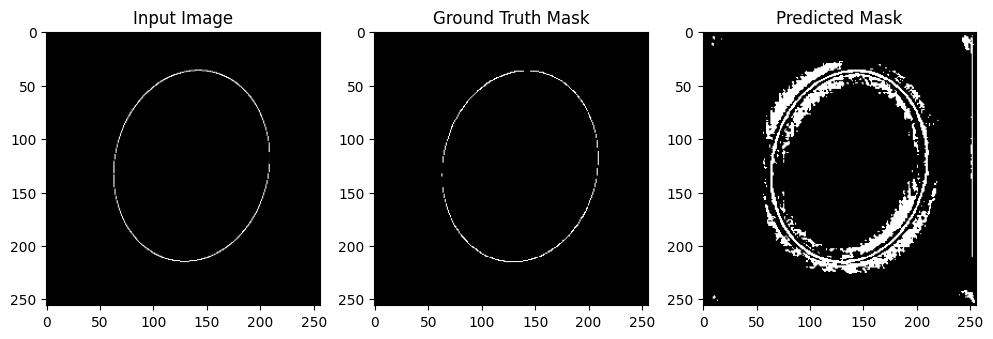

In [ ]:
import matplotlib.pyplot as plt

def visualize_prediction(model, dataset, index=0):
    model.eval()
    image, true_mask = dataset[index]
    image_tensor = image.unsqueeze(0).to(device)  # Add batch dim

    with torch.no_grad():
        pred_mask = model(image_tensor)
        pred_mask = torch.sigmoid(pred_mask)
        pred_mask = (pred_mask > 0.5).float()

    # Convert to numpy
    img_np = image.squeeze().cpu().numpy()
    true_mask_np = true_mask.squeeze().cpu().numpy()
    pred_mask_np = pred_mask.squeeze().cpu().numpy()

    # Plot
    plt.figure(figsize=(12, 4))
    plt.subplot(1, 3, 1)
    plt.imshow(img_np, cmap='gray')
    plt.title("Input Image")

    plt.subplot(1, 3, 2)
    plt.imshow(true_mask_np, cmap='gray')
    plt.title("Ground Truth Mask")

    plt.subplot(1, 3, 3)
    plt.imshow(pred_mask_np, cmap='gray')
    plt.title("Predicted Mask")

    plt.show()

# Example usage:
visualize_prediction(model, val_dataset, index=5)


In [ ]:
import matplotlib.pyplot as plt

# Metrics from your logs
train_loss = [
    1.1743, 0.6905, 0.3549, 0.2273, 0.1783, 0.1539, 0.1340, 0.1221, 0.1174, 0.1044,
    0.0982, 0.1007, 0.0882, 0.0845, 0.0832, 0.0760, 0.0806, 0.0773, 0.0734, 0.0708,
    0.0677, 0.0683, 0.0654, 0.0660, 0.0621, 0.0629, 0.0607, 0.0584, 0.0601, 0.0576
]
val_loss = [
    0.9812, 0.5187, 0.9162, 0.2950, 0.2608, 0.4858, 0.1556, 0.2574, 0.3029, 2.9015,
    0.3260, 0.1396, 0.7322, 1.0240, 0.2109, 1.2590, 0.5950, 0.8246, 0.7286, 0.5589,
    1.0620, 0.1329, 0.1276, 1.7473, 0.2781, 0.9825, 0.0814, 0.5629, 0.8937, 1.0937
]
dice_scores = [
    0.6100, 0.7806, 0.2035, 0.7874, 0.8051, 0.6364, 0.8845, 0.8075, 0.7653, 0.0929,
    0.7585, 0.8901, 0.4658, 0.2970, 0.8376, 0.4206, 0.5815, 0.5613, 0.5177, 0.6120,
    0.4916, 0.8984, 0.9018, 0.2744, 0.8087, 0.3389, 0.9364, 0.6860, 0.5587, 0.5007
]
iou_scores = [
    0.4450, 0.6420, 0.1152, 0.6528, 0.6765, 0.4734, 0.7938, 0.6820, 0.6243, 0.0494,
    0.6171, 0.8032, 0.3223, 0.1825, 0.7219, 0.2786, 0.4312, 0.4033, 0.3735, 0.4646,
    0.3397, 0.8170, 0.8222, 0.1603, 0.6831, 0.2112, 0.8810, 0.5314, 0.4020, 0.3481
]

epochs = range(1, 31)


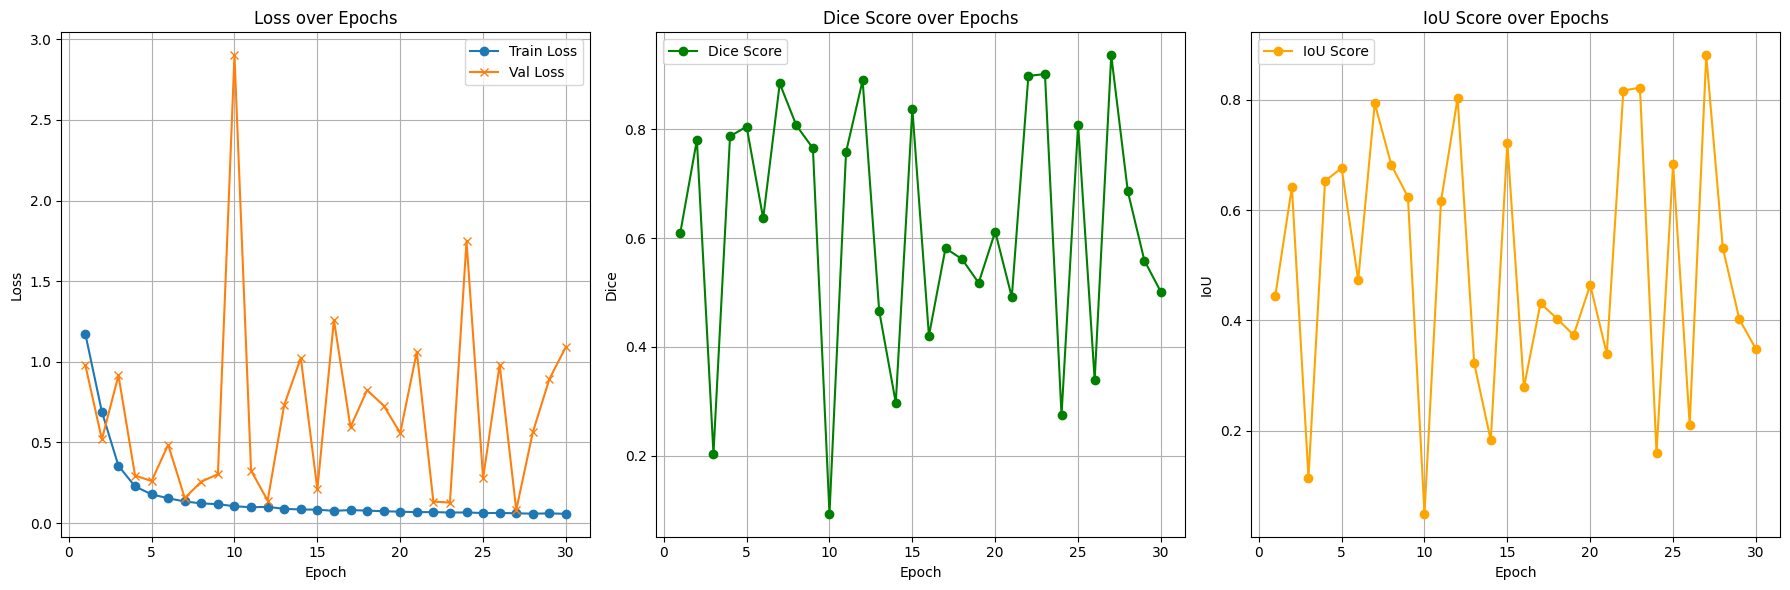

In [ ]:
plt.figure(figsize=(18, 6))

# Loss
plt.subplot(1, 3, 1)
plt.plot(epochs, train_loss, label='Train Loss', marker='o')
plt.plot(epochs, val_loss, label='Val Loss', marker='x')
plt.title('Loss over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

# Dice Score
plt.subplot(1, 3, 2)
plt.plot(epochs, dice_scores, label='Dice Score', color='green', marker='o')
plt.title('Dice Score over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Dice')
plt.legend()
plt.grid(True)

# IoU Score
plt.subplot(1, 3, 3)
plt.plot(epochs, iou_scores, label='IoU Score', color='orange', marker='o')
plt.title('IoU Score over Epochs')
plt.xlabel('Epoch')
plt.ylabel('IoU')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()


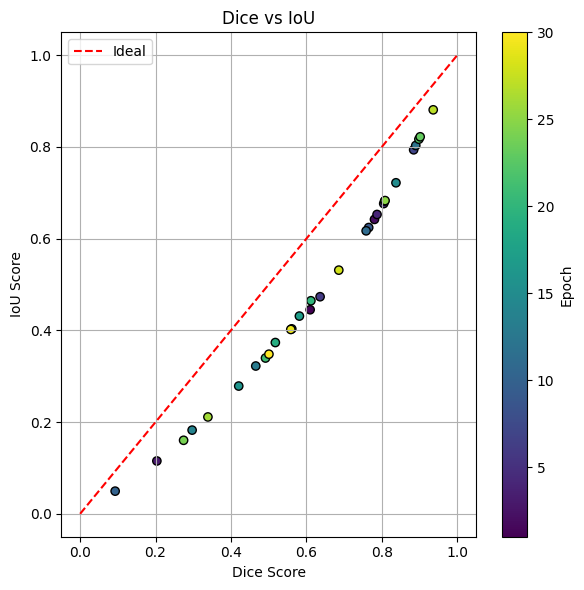

In [ ]:
plt.figure(figsize=(6, 6))
plt.scatter(dice_scores, iou_scores, c=range(1, 31), cmap='viridis', edgecolor='k')
plt.plot([0, 1], [0, 1], 'r--', label='Ideal')
plt.title('Dice vs IoU')
plt.xlabel('Dice Score')
plt.ylabel('IoU Score')
plt.colorbar(label='Epoch')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


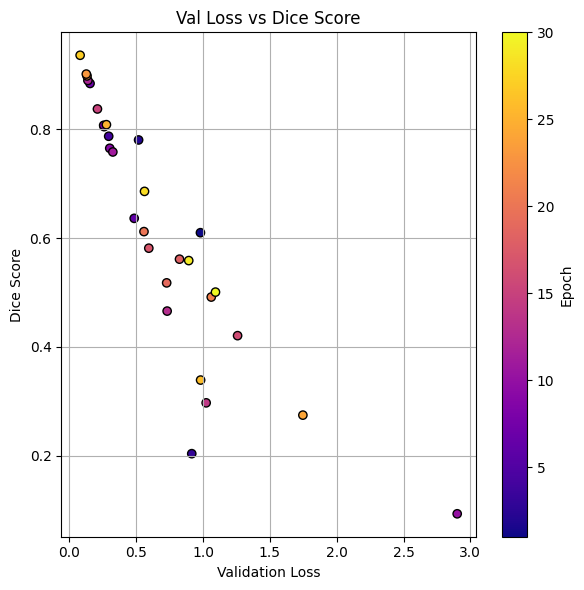

In [ ]:
plt.figure(figsize=(6, 6))
plt.scatter(val_loss, dice_scores, c=range(1, 31), cmap='plasma', edgecolor='k')
plt.xlabel('Validation Loss')
plt.ylabel('Dice Score')
plt.title('Val Loss vs Dice Score')
plt.colorbar(label='Epoch')
plt.grid(True)
plt.tight_layout()
plt.show()


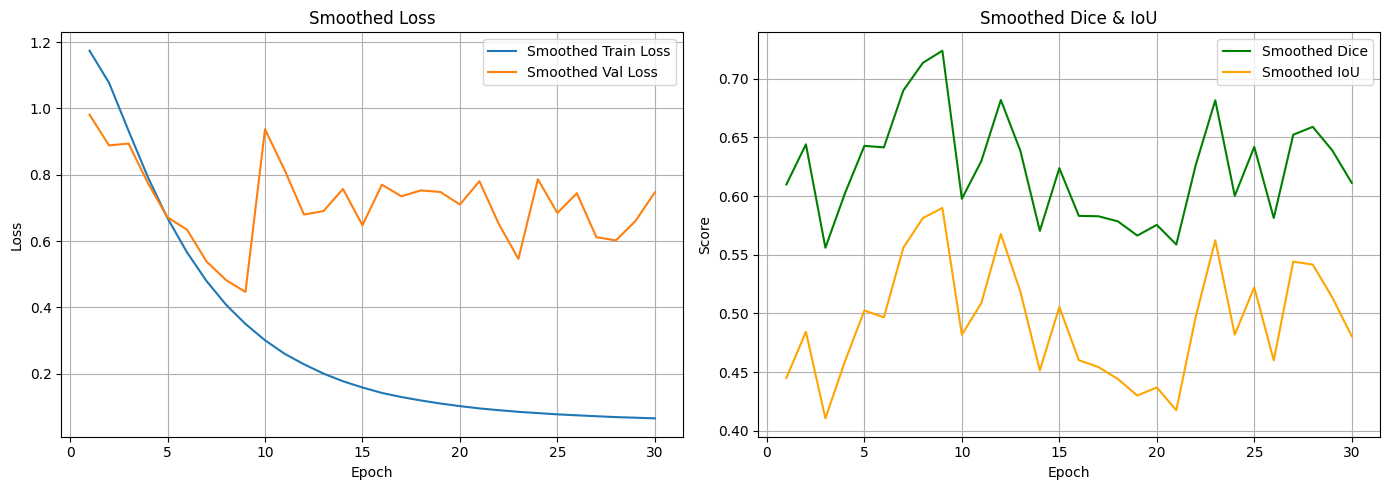

In [ ]:
import numpy as np

def smooth_curve(points, factor=0.8):
    smoothed = []
    for i, point in enumerate(points):
        if i == 0:
            smoothed.append(point)
        else:
            smoothed.append(smoothed[-1] * factor + point * (1 - factor))
    return smoothed

plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(epochs, smooth_curve(train_loss), label='Smoothed Train Loss')
plt.plot(epochs, smooth_curve(val_loss), label='Smoothed Val Loss')
plt.title('Smoothed Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(epochs, smooth_curve(dice_scores), label='Smoothed Dice', color='green')
plt.plot(epochs, smooth_curve(iou_scores), label='Smoothed IoU', color='orange')
plt.title('Smoothed Dice & IoU')
plt.xlabel('Epoch')
plt.ylabel('Score')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()


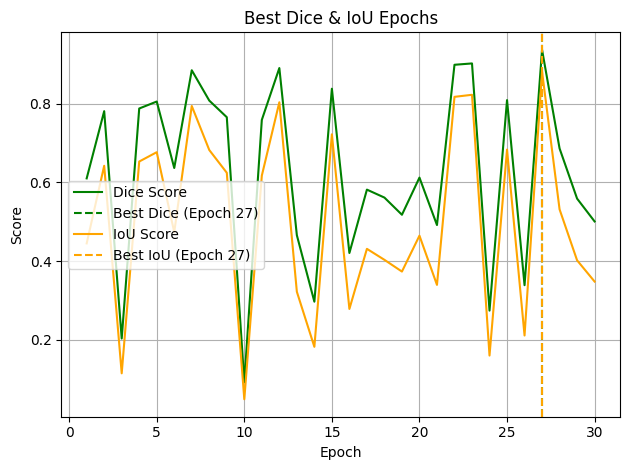

In [ ]:
best_dice_epoch = np.argmax(dice_scores) + 1
best_iou_epoch = np.argmax(iou_scores) + 1

plt.plot(epochs, dice_scores, label='Dice Score', color='green')
plt.axvline(best_dice_epoch, color='green', linestyle='--', label=f'Best Dice (Epoch {best_dice_epoch})')
plt.plot(epochs, iou_scores, label='IoU Score', color='orange')
plt.axvline(best_iou_epoch, color='orange', linestyle='--', label=f'Best IoU (Epoch {best_iou_epoch})')
plt.xlabel('Epoch')
plt.ylabel('Score')
plt.title('Best Dice & IoU Epochs')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [ ]:
model.eval()
with torch.no_grad():
    pred = model(image_tensor)
    pred = torch.sigmoid(pred)
    pred_mask = pred.squeeze().cpu().numpy()
    pred_mask_bin = (pred_mask > 0.5).astype(np.uint8)
    print(pred.min(), pred.max())



In [ ]:
model.eval()


UnetPlusPlus(
  (encoder): ResNetEncoder(
    (conv1): Conv2d(1, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (layer1): Sequential(
      (0): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
      (1): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=Tru

In [ ]:
def compute_segmentation_metrics(y_pred, y_true, threshold=0.5):

    y_pred = (y_pred > threshold).astype(np.uint8)
    y_true = y_true.astype(np.uint8)

    TP = np.sum((y_pred == 1) & (y_true == 1))
    TN = np.sum((y_pred == 0) & (y_true == 0))
    FP = np.sum((y_pred == 1) & (y_true == 0))
    FN = np.sum((y_pred == 0) & (y_true == 1))

    epsilon = 1e-7  # to avoid division by zero

    precision = TP / (TP + FP + epsilon)
    recall = TP / (TP + FN + epsilon)
    specificity = TN / (TN + FP + epsilon)
    accuracy = (TP + TN) / (TP + TN + FP + FN + epsilon)
    f1 = 2 * precision * recall / (precision + recall + epsilon)
    iou = TP / (TP + FP + FN + epsilon)
    dice = 2 * TP / (2 * TP + FP + FN + epsilon)

    return {
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'Specificity': specificity,
        'F1-Score': f1,
        'IoU': iou,
        'Dice': dice
    }


In [ ]:
pip install medpy


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 156.3/156.3 kB 10.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.6/52.6 MB 19.5 MB/s eta 0:00:00
  Created wheel for medpy: filename=MedPy-0.5.2-py3-none-any.whl size=224710 sha256=da332925b481576c9f5c3232c6210dc767508b9408b6bfa49b80cc6ea458d63e
  Stored in directory: /root/.cache/pip/wheels/d4/33/ed/aaac5a347fb8d41679ca515b8f5c49dfdf49be15bdbb9a905d
Successfully built medpy


In [ ]:
import torch
import torch.nn.functional as F

def tversky_index(preds, targets, alpha=0.5, beta=0.5, smooth=1e-6):
    preds = torch.sigmoid(preds)
    preds = preds.view(-1)
    targets = targets.view(-1)

    TP = (preds * targets).sum()
    FP = ((1 - targets) * preds).sum()
    FN = (targets * (1 - preds)).sum()

    return (TP + smooth) / (TP + alpha * FP + beta * FN + smooth)


In [ ]:
import torch

def tversky_index(preds, targets, alpha=0.7, beta=0.3, smooth=1e-6):
    preds = torch.sigmoid(preds)  # ensure values are between 0 and 1
    preds = preds.view(-1)
    targets = targets.view(-1)

    TP = (preds * targets).sum()
    FP = ((1 - targets) * preds).sum()
    FN = (targets * (1 - preds)).sum()

    return (TP + smooth) / (TP + alpha * FP + beta * FN + smooth)

def focal_tversky_loss(preds, targets, alpha=0.7, beta=0.3, gamma=0.75, smooth=1e-6):
    tversky = tversky_index(preds, targets, alpha, beta, smooth)
    return torch.pow((1 - tversky), gamma)

# Example usage
# Simulated logits (e.g., output of model) and ground truth
logits = torch.randn(1, 1, 256, 256)  # raw predictions
masks = torch.randint(0, 2, (1, 1, 256, 256)).float()  # binary ground truth

# Compute scores
t_index = tversky_index(logits, masks).item()
focal_loss = focal_tversky_loss(logits, masks).item()

# Print scores
print(f"Tversky Index: {t_index:.4f}")
print(f"Focal Tversky Loss: {focal_loss:.4f}")


Tversky Index: 0.5027
Focal Tversky Loss: 0.5922


In [ ]:
from tqdm import tqdm
import torch # Ensure torch is imported
import torch.nn.functional as F # Ensure F is imported if needed by other functions

def train_one_epoch(model, loader, optimizer, device):
    model.train()
    epoch_loss = 0
    for images, masks in tqdm(loader):
        images = images.to(device)
        masks = masks.to(device)

        optimizer.zero_grad()
        outputs = model(images)

        # Use the new focal_tversky_loss here
        loss = focal_tversky_loss(outputs, masks) # This line is the change

        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()
    return epoch_loss / len(loader)

@torch.no_grad()
def evaluate(model, loader, device):
    model.eval()
    total_dice = 0
    total_iou = 0
    total_loss = 0 # This will now track the combined_loss or focal_tversky_loss

    for images, masks in loader:
        images = images.to(device)
        masks = masks.to(device)

        outputs = model(images)


        loss = focal_tversky_loss(outputs, masks) # This line is the change


        total_loss += loss.item()
        # Keep the dice and iou score calculations as they use the model outputs, not the specific loss function
        total_dice += dice_score(outputs, masks).item()
        total_iou += iou_score(outputs, masks).item()

    return total_loss / len(loader), total_dice / len(loader), total_iou / len(loader)

In [ ]:
model.eval()
with torch.no_grad():
    pred = model(image_tensor)
    pred = torch.sigmoid(pred)
    pred_mask = pred.squeeze().cpu().numpy() # This line defines pred_mask
    pred_mask_bin = (pred_mask > 0.5).astype(np.uint8)
    print(pred.min(), pred.max())

tensor(9.2374e-15, device='cuda:0') tensor(1., device='cuda:0')


In [2]:
model.eval()
with torch.no_grad():

    sample_index = 5
    image, true_mask = val_dataset[sample_index]


    image_tensor = image.unsqueeze(0).to(device)

    pred = model(image_tensor)
    pred = torch.sigmoid(pred)
    pred_mask = pred.squeeze().cpu().numpy()
    pred_mask_bin = (pred_mask > 0.5).astype(np.uint8)
    print(pred.min(), pred.max())


metrics = compute_segmentation_metrics(pred_mask, true_mask.squeeze().cpu().numpy())
print(metrics)


true_mask_np = true_mask.squeeze().cpu().numpy()

hd_value = hd95(pred_mask_bin, true_mask_np)
assd_value = assd(pred_mask_bin, true_mask_np)
print(f"HD95: {hd_value:.4f}")
print(f"ASSD: {assd_value:.4f}")

NameError: name 'model' is not defined

In [ ]:

Abstract
This work presents UNet++ with a ResNet encoder, a convolutional neural network architecture designed for precise image segmentation tasks. The model integrates a powerful ResNet-based encoder that effectively captures hierarchical features through residual learning, enabling deep feature extraction with improved gradient flow. The encoder consists of multiple convolutional layers grouped into residual blocks, progressively downsampling the input while preserving rich contextual information.

The decoder employs the UNet++ structure, characterized by nested and dense skip connections that enhance feature fusion between encoder and decoder stages at multiple resolutions. Decoder blocks utilize convolutional layers with batch normalization and ReLU activations, combined with attention mechanisms to emphasize salient features during upsampling. This design facilitates multi-scale feature aggregation, improving segmentation accuracy especially in complex images.

Overall, UNet++ with ResNet encoder achieves robust performance by combining deep residual feature extraction with advanced decoder skip pathways, making it suitable for medical imaging, remote sensing, and other applications requiring detailed pixel-level classification.

In [ ]:
training loss
validation loss
HD95 (Hausdorff Distance @ 95th percentile)
ASSD (Average Symmetric Surface Distance)
DiceLoss
IOU
BCEWithLogitsLoss
focal_tversky_loss
Tversky Index
accuracy
precision
recall
specificity
f1-score


